In [3]:
import pandas as pd

df = pd.read_csv("healthcare_data_cleaning_dataset.csv")
df.head()

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
0,17270,35.0,Male,Bangalore,Hypertension,13,41010.0,1,2023-11-30
1,10860,21.0,Female,Hyderabad,Flu,11,12194.0,1,2023-02-23
2,15390,77.0,Female,Bangalore,Asthma,2,45086.0,0,2023-03-14
3,15191,79.0,Female,Mumbai,Asthma,13,40842.0,0,2023-08-01
4,15734,60.0,Female,Delhi,Asthma,1,9873.0,1,2023-06-20


In [8]:
#Q1. Missing Data Identification

# Identify missing values
df.isnull().sum()

Patient_ID              0
Age                   600
Gender                  0
City                    0
Diagnosis               0
Hospital_Visits         0
Treatment_Cost        593
Insurance_Coverage      0
Admission_Date          0
dtype: int64

In [12]:
# Calculate percentage
df.isnull().sum() / len(df) * 100

Patient_ID             0.000000
Age                   11.764706
Gender                 0.000000
City                   0.000000
Diagnosis              0.000000
Hospital_Visits        0.000000
Treatment_Cost        11.627451
Insurance_Coverage     0.000000
Admission_Date         0.000000
dtype: float64

In [17]:
#Q2. Handling Missing Age

df['Age'] = df['Age'].fillna(df['Age'].median())

In [18]:
# Q3: Handling Treatment Cost (using Median due to skewness)

df['Treatment_Cost'] = df['Treatment_Cost'].fillna(df['Treatment_Cost'].median())

In [20]:
#Q4. Duplicate Patient Records

print(f"Original size: {df.shape}")
# Identify and remove
df = df.drop_duplicates()
print(f"New size: {df.shape}")

Original size: (5100, 9)
New size: (5001, 9)


In [21]:
#Q5. Invalid Age Values

# Detect and remove unrealistic records
df = df[(df['Age'] >= 0) & (df['Age'] <= 100)]

In [22]:
# Q6: Detect Outliers using IQR

Q1 = df['Treatment_Cost'].quantile(0.25)
Q3 = df['Treatment_Cost'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Treatment_Cost'] < (Q1 - 1.5 * IQR)) | (df['Treatment_Cost'] > (Q3 + 1.5 * IQR))]
print(f"Number of outliers: {len(outliers)}")

Number of outliers: 50


In [23]:
# Q7: Capping (Winsorization)

lower_limit = df['Treatment_Cost'].quantile(0.05)
upper_limit = df['Treatment_Cost'].quantile(0.95)
df['Treatment_Cost'] = df['Treatment_Cost'].clip(lower_limit, upper_limit)

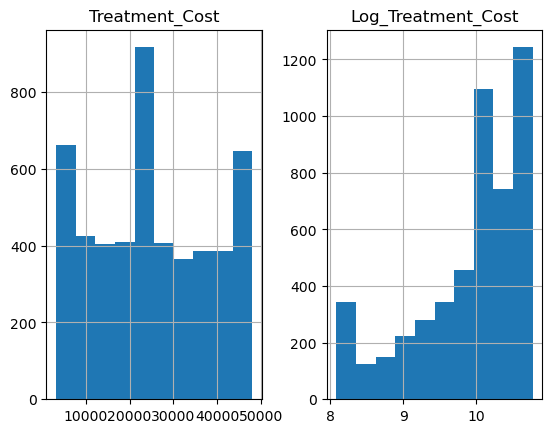

In [25]:
#Q8. Log Transformation

import numpy as np
import matplotlib.pyplot as plt

df['Log_Treatment_Cost'] = np.log1p(df['Treatment_Cost']) # log1p handles zero values [cite: 50]

# Compare distribution
df[['Treatment_Cost', 'Log_Treatment_Cost']].hist()
plt.show()

In [28]:
#Q9. Time-Based Missing Handling

# Sort by date first
df = df.sort_values('Admission_Date')

# Apply Forward Fill
df['Admission_Date'] = df['Admission_Date'].ffill()